In [18]:
import re
import os

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from plotly.colors import sample_colorscale

# Reading files from the directory

In [19]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/ppi_different_bits/ppi_relu_quantized_results_for_appendix_7.csv
/kaggle/input/ppi_different_bits/ppi_relu_quantized_results_for_appendix_6.csv
/kaggle/input/ppi_different_bits/ppi_relu6_quantized_results_for_appendix_5.csv
/kaggle/input/ppi_different_bits/ppi_softplus_quantized_results_for_appendix_8.csv
/kaggle/input/ppi_different_bits/ppi_softplus_quantized_results_for_appendix_2.csv
/kaggle/input/ppi_different_bits/ppi_softplus_quantized_results_for_appendix_32.csv
/kaggle/input/ppi_different_bits/ppi_elu_quantized_results_for_appendix_7.csv
/kaggle/input/ppi_different_bits/ppi_gelu_quantized_results_for_appendix_5.csv
/kaggle/input/ppi_different_bits/ppi_silu_quantized_results_for_appendix_32.csv
/kaggle/input/ppi_different_bits/ppi_relu6_quantized_results_for_appendix_32.csv
/kaggle/input/ppi_different_bits/ppi_relu6_quantized_results_for_appendix_4.csv
/kaggle/input/ppi_different_bits/ppi_sigmoid_quantized_results_for_appendix_16.csv
/kaggle/input/ppi_different_bit

#  Information about data

The experimental part of this article is based on the article Barcelo et al. in which the authors focused on the aggregate-combine graph neural networks (AC-GNNs) and aggregate-combine-readout GNNs (ACR-GNNs)

**Paper**: [The Logical Expressiveness of Graph Neural Networks](https://openreview.net/forum?id=r1lZ7AEKvB)  
**Code**: [GNN-logic GitHub Repository](https://github.com/juanpablos/GNN-logic.git)  


## Complex $\text{FOC}_2$ Formula

Classifier $\alpha_i(x)$ constructed as:
\begin{equation*}
    \alpha_0(x):= \text{Blue}(x), \alpha_{i+1}(x):=  \exists^{[N,M]}y\left(\alpha_i(y) \wedge \neg E(x,y)\right)
\end{equation*}
where $\exists^{[N,M]}$ stands for ''there exist between $N$ and $M$ nodes''. satisfying a given property.

Observe that each $\alpha_i(x)$ is in FOC$_2$, as $\exists^{[N,M]}$ can be expressed by combining $\exists^{\geq N}$ and $\neg \exists^{\geq M + 1}$.

The data set has the following specifications: Erdos-Renyi graphs and is labeled according to $\alpha_1(x)$, $\alpha_2(x)$, and $\alpha_3(x)$:

* $\alpha_0(x):= \text{Blue}(x)$
* $\alpha_1(x) := \exists^{[8,10]}y\left(\alpha_0(y) \wedge \neg E(x,y)\right)$
* $\alpha_2(x) := \exists^{[10,30]}y\left(\alpha_1(y) \wedge \neg E(x,y)\right)$
* $\alpha_3(x) := \exists^{[10,30]}y\left(\alpha_2(y) \wedge \neg E(x,y)\right)$

In the case of code:
* $p1: \alpha_1(x) := \exists^{[8,10]}y\left(\alpha_0(y) \wedge \neg E(x,y)\right)$
* $p2: \alpha_2(x) := \exists^{[10,30]}y\left(\alpha_1(y) \wedge \neg E(x,y)\right)$
* $p3: \alpha_3(x) := \exists^{[10,30]}y\left(\alpha_2(y) \wedge \neg E(x,y)\right)$

# Activation functions

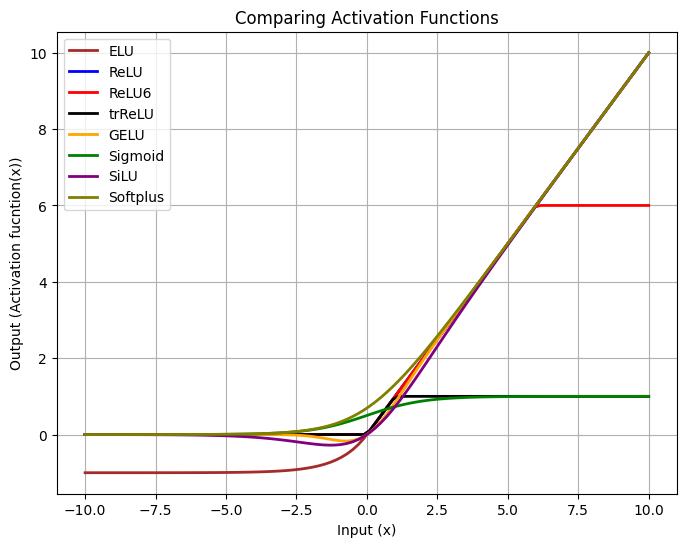

In [20]:
x = torch.linspace(-10, 10, 100)
elu=nn.ELU()
relu=nn.ReLU()
relu6=nn.ReLU6()
hardtanh = nn.Hardtanh(0, 1)
gelu=nn.GELU()
sigmoid = nn.Sigmoid()
silu=nn.SiLU()
softplus=nn.Softplus()
plt.figure(figsize=(8, 6))

plt.plot(x.numpy(), elu(x).numpy(), label="ELU", color="brown", linewidth=2)
plt.plot(x.numpy(), relu(x).numpy(), label="ReLU", color="blue", linewidth=2)
plt.plot(x.numpy(), relu6(x).numpy(), label="ReLU6", color="red", linewidth=2)
plt.plot(x.numpy(), hardtanh(x).numpy(), label="trReLU", color="black", linewidth=2)
plt.plot(x.numpy(), gelu(x).numpy(), label="GELU", color="orange", linewidth=2)
plt.plot(x.numpy(), sigmoid(x).numpy(), label="Sigmoid", color="green", linewidth=2)
plt.plot(x.numpy(), silu(x).numpy(), label="SiLU", color="purple", linewidth=2)
plt.plot(x.numpy(), softplus(x).numpy(), label="Softplus", color="olive", linewidth=2)

plt.xlabel("Input (x)")
plt.ylabel("Output (Activation fucntion(x))")
plt.title("Comparing Activation Functions")
plt.legend()
plt.grid(True)
#plt.savefig('all_plus_ELU.png')
plt.show()


# Function for writing keys

In [21]:
def print_keys(key):
    latex_map = {
        "p1": r"$p1: \alpha_1(x) := \exists^{[8,10]}y\left(\alpha_0(y) \wedge \neg E(x,y)\right)$",
        "p2": r"$p2: \alpha_2(x) := \exists^{[10,30]}y\left(\alpha_1(y) \wedge \neg E(x,y)\right)$",
        "p3": r"$p3: \alpha_3(x) := \exists^{[10,30]}y\left(\alpha_2(y) \wedge \neg E(x,y)\right)$"
    }
    clean_latex = re.sub(r'[\x00-\x1F\x7F]', '', latex_map.get(key, ''))
    return clean_latex

In [22]:
def process_dataframe(dataframe):
    def extract_params(model_name):
        pattern1 = r"saved_models/results/(?P<key>[^/]+)/(?:MODEL-)acr?gnn(?:-single)?-(?:[^-]+-){4}cl(?P<comb_layers>\d+)-L(?P<l>\d+)-H\d+\.pth"
        pattern2 = r"(?P<key>p\d+)-0-0-ac(?:rgnn|gnn)(?:-single)?-agg\w+-read\w+-comb\w+-cl(?P<comb_layers>\d+)-L(?P<l>\d+)\.log"
        pattern3 = r"saved_models/results__ac(?:rgnn|gnn)_trRELU/(?P<key>[^/]+)/(?:MODEL-)acr?gnn(?:-single)?-(?:[^-]+-){4}cl(?P<comb_layers>\d+)-L(?P<l>\d+)-H\d+\.pth"	
        #pattern_acgnn = r"(?P<key>p\d+)-0-0-acgnn-aggS-readS-combT-cl(?P<comb_layers>\d+)-L(?P<l>\d+)\.log"
        #pattern_acrgnn =r"(?P<key>p\d+)-0-0-acrgnn-aggS-readS-combT-cl(?P<comb_layers>\d+)-L(?P<l>\d+)\.log"
        #pattern_acrgnn_single =r"(?P<key>p\d+)-0-0-acrgnn-single-aggS-readS-combT-cl(?P<comb_layers>\d+)-L(?P<l>\d+)\.log"


        case1 = re.search(pattern1, model_name)
        case2 = re.search(pattern2, model_name)
        case3 = re.search(pattern3, model_name)
        #acgnn = re.search(pattern_acgnn, model_name)
        #acrgnn = re.search(pattern_acrgnn, model_name)
        #acrgnn_single = re.search(pattern_acrgnn_single, model_name)
        
        if case1: 
            key = case1.group('key')
            comb_layers = int(case1.group('comb_layers'))
            l = int(case1.group('l'))
        elif case2:  
            key = case2.group('key')
            comb_layers = int(case2.group('comb_layers'))
            l = int(case2.group('l'))
        elif case3:
            key = case3.group('key')
            comb_layers = int(case3.group('comb_layers'))
            l = int(case3.group('l'))
        else:  
            return pd.Series({'key': None, 'comb_layers': None, 'l': None})

        return pd.Series({'key': key, 'comb_layers': comb_layers, 'l': l})


    extracted_df = dataframe["model_name"].apply(extract_params)

    
    dataframe = pd.concat([dataframe, extracted_df], axis=1)

    
    cols = dataframe.columns.tolist()
    new_order = ['key', 'comb_layers', 'l'] + [col for col in cols if col not in ['key', 'comb_layers', 'l']]
    dataframe = dataframe[new_order]  
    dataframe=dataframe.drop("model_name",axis=1)
    return dataframe 

# [dPTQ] Analysis. How number of bits for the dPTQ influence on the model

## [dPTQ_bits] Read the data

In [23]:
file_path_different_bits = "/kaggle/input/results_synthetic_different_bits/"

In [24]:
# Path 
data_path = f"{file_path_different_bits}"

# Collect all .csv files in the folder
csv_files = [f for f in os.listdir(data_path) if f.endswith(".csv")]

# Read them into a dictionary of DataFrames
dfs_dptq_different_bits = {os.path.splitext(f)[0]: pd.read_csv(os.path.join(data_path, f)) for f in csv_files}

for name, df in dfs_dptq_different_bits.items():
    print(f"{name}: {df.shape}")

standart_dymanic_quantized_results_size_time_pytorch_acrgnn_relu6_6: (9, 14)
standart_dymanic_quantized_results_size_time_pytorch_acrgnn_trrelu_2: (30, 14)
standart_dymanic_quantized_results_size_time_pytorch_acrgnn_elu_5: (9, 14)
standart_dymanic_quantized_results_size_time_pytorch_acrgnn_relu6_8: (30, 14)
standart_dymanic_quantized_results_size_time_pytorch_acrgnn_sigmoid_32: (30, 14)
standart_dymanic_quantized_results_size_time_pytorch_acrgnn_silu_7: (9, 14)
standart_dymanic_quantized_results_size_time_pytorch_acrgnn_gelu_5: (9, 14)
standart_dymanic_quantized_results_size_time_pytorch_acrgnn_trrelu_4: (30, 14)
standart_dymanic_quantized_results_size_time_pytorch_acrgnn_elu_7: (9, 14)
standart_dymanic_quantized_results_size_time_pytorch_acrgnn_sigmoid_5: (9, 14)
standart_dymanic_quantized_results_size_time_pytorch_acrgnn_sigmoid_8: (30, 14)
standart_dymanic_quantized_results_size_time_pytorch_acrgnn_softplus_8: (30, 14)
standart_dymanic_quantized_results_size_time_pytorch_acrgnn_relu

In [25]:
files_under_analysis='standart_dymanic_quantized_results_size_time_pytorch_acrgnn'

In [26]:
options_of_activations = ["relu", "relu6", "trrelu", "gelu", "sigmoid", "silu", "softplus", "elu"]
bitwidths = [32, 16, 8,7,6,5, 4, 2]

for activation in options_of_activations:
    for bits in bitwidths:
        
        key = f"{files_under_analysis}_{activation}_{bits}"
        
        # Check if key exists
        if key not in dfs_dptq_different_bits:
            print(f"Skipping: {key} — not found in dictionary.")
            continue
        
        df = dfs_dptq_different_bits[key]

        df = process_dataframe(df.rename(columns={"file": "model_name"})).drop(columns="comb_layers")

        dfs_dptq_different_bits[key] = df


In [27]:
def plot_comparizon_bits(options_of_activations,bitwidths,short_array):
    splits = [
        ("Train", "train_micro", 0),
        ("Test1", "test1_micro", 1),
        ("Test2", "test2_micro", 2),
    ]
    
    for selected_key in ["p1", "p2", "p3"]:
        readable_key = print_keys(selected_key)
    
        for activation in options_of_activations:
    
            fig, axes = plt.subplots(
                nrows=1,
                ncols=len(splits),
                figsize=(15, 4),
                sharex=True,
                sharey=True
            )
    
            if len(splits) == 1:
                axes = [axes]
    
            for (split_name, col_name, idx) in splits:
                ax = axes[idx]
    
                for bits in bitwidths:
                    key = f"{files_under_analysis}_{activation}_{bits}"
                    if key not in dfs_dptq_different_bits:
                        print(key)
                        continue
    
                    df = dfs_dptq_different_bits[key][
                        ["key", "bits", "l", "train_micro", "test1_micro", "test2_micro"]
                    ].copy()
                    
    
                    df_sel = df[df["key"] == selected_key].copy()
                    df_sel = df_sel[df_sel["l"]<short_array].copy()
                    if df_sel.empty:
                        continue
    
                    df_sel = df_sel.sort_values("l")
                    
                    ax.plot(
                        df_sel["l"],
                        df_sel[col_name],
                        marker="o",
                        linewidth=2,
                        markersize=6,
                        label=f"{bits} bits"
                    )
    
                ax.set_title(f"{split_name}", fontsize=12)
                ax.set_xlabel("Layers (L)", fontsize=11)
                ax.grid(True, linestyle="--", alpha=0.5)
    
                if idx == 0:
                    ax.set_ylabel("Micro Accuracy", fontsize=11)
    
            handles, labels = axes[-1].get_legend_handles_labels()
            axes[-1].legend(
                handles,
                labels,
                title="Bit-width",
                fontsize=9,
                title_fontsize=10,
                bbox_to_anchor=(1.04, 0.5), loc="center left", borderaxespad=0
            )
    
            fig.suptitle(
                f"ACR-GNN, activation={activation}, classifier={readable_key}",
                fontsize=14
            )
    
            plt.tight_layout(rect=[0, 0.02, 1, 0.9])  # leave space for suptitle
            plt.show()


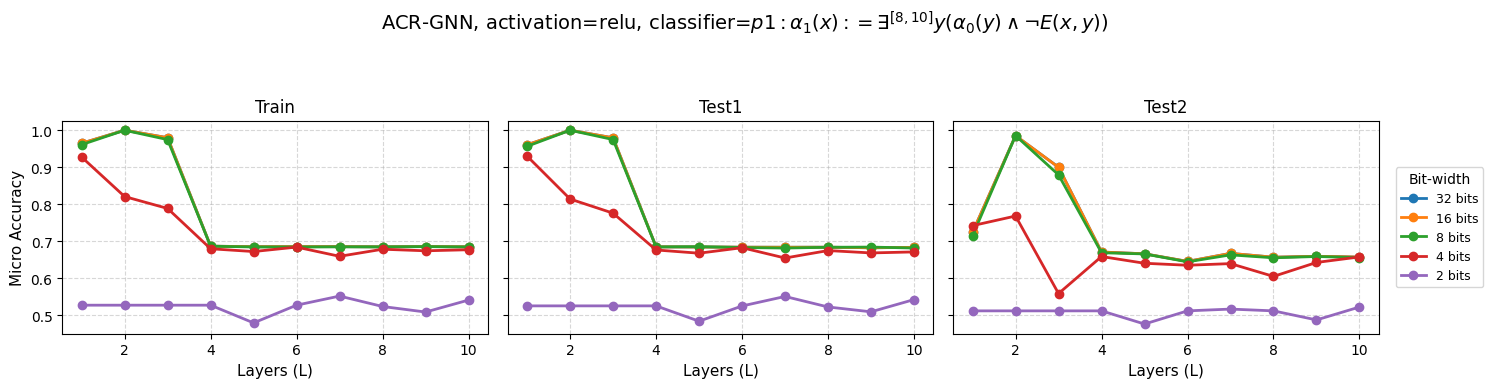

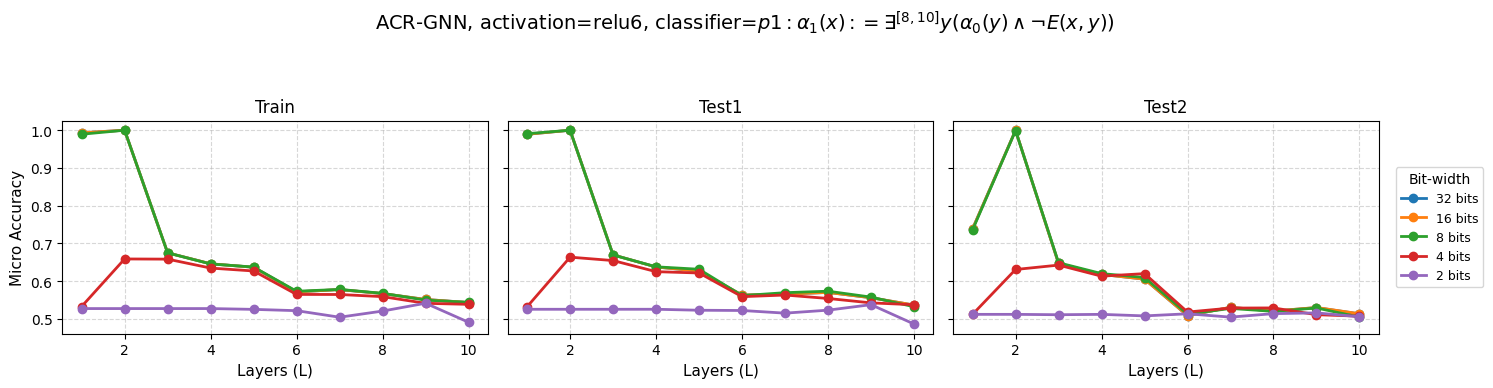

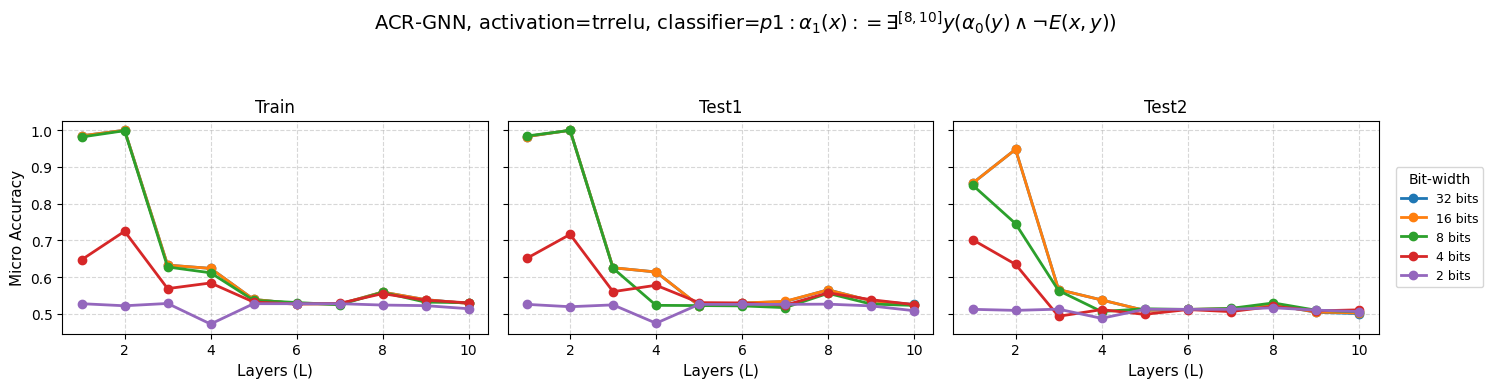

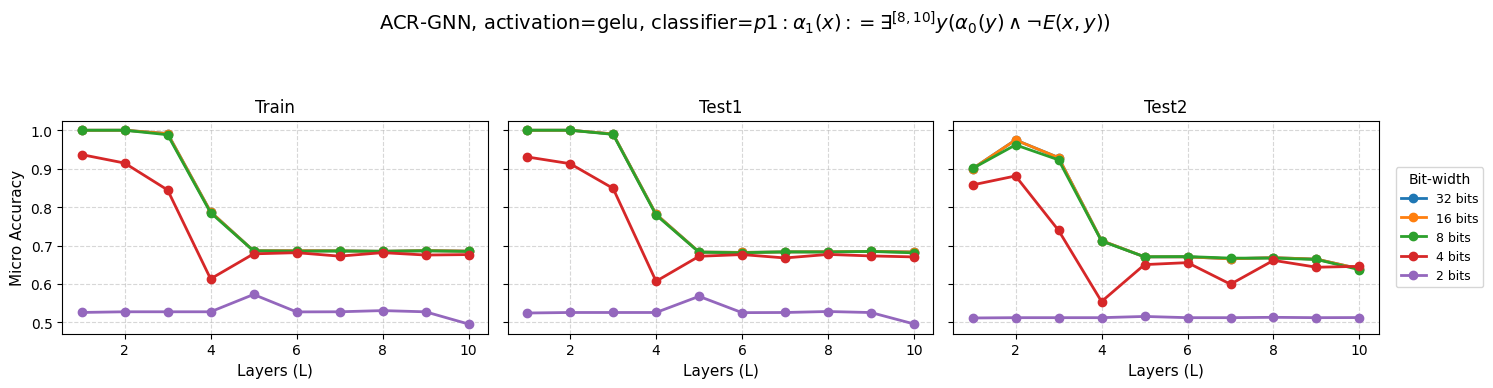

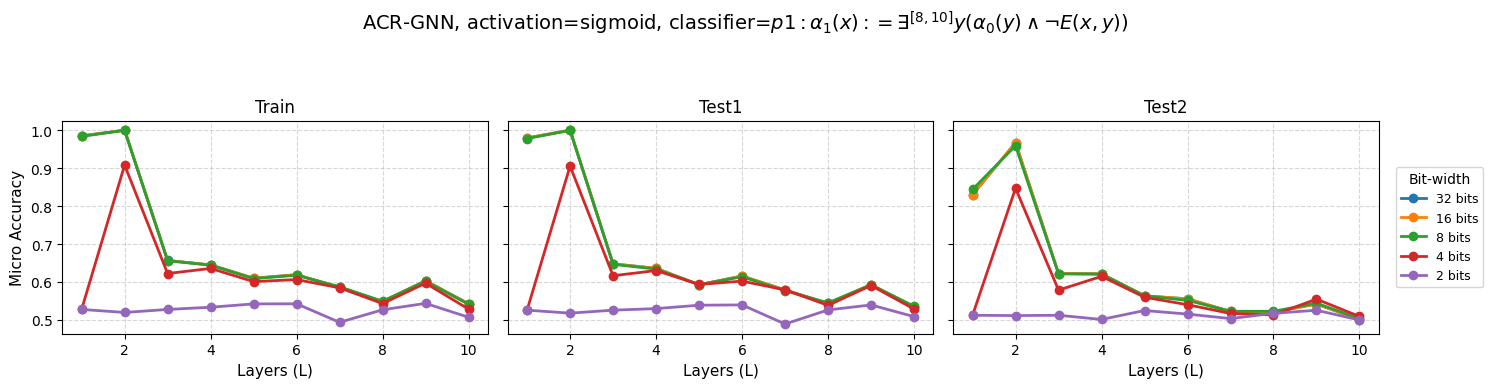

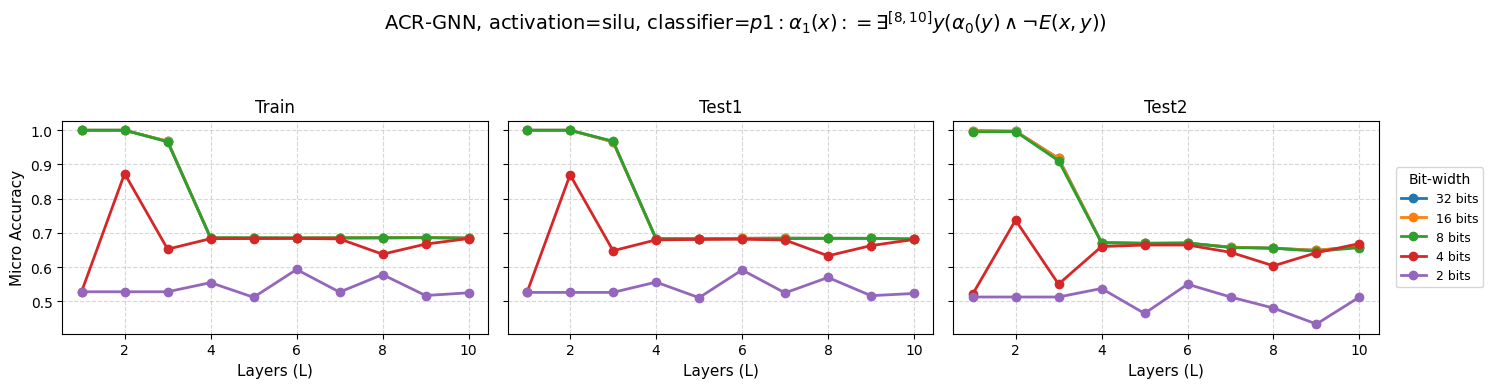

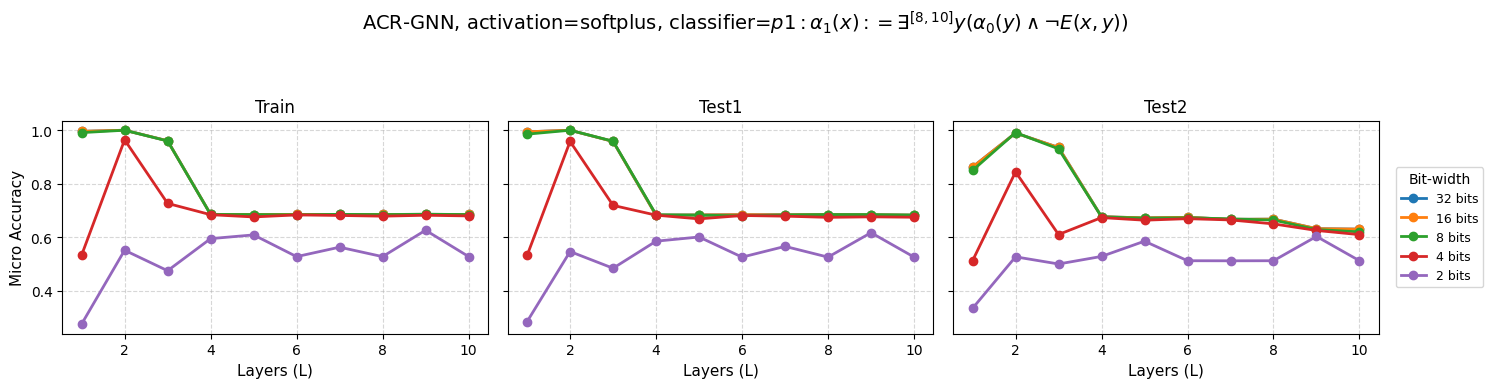

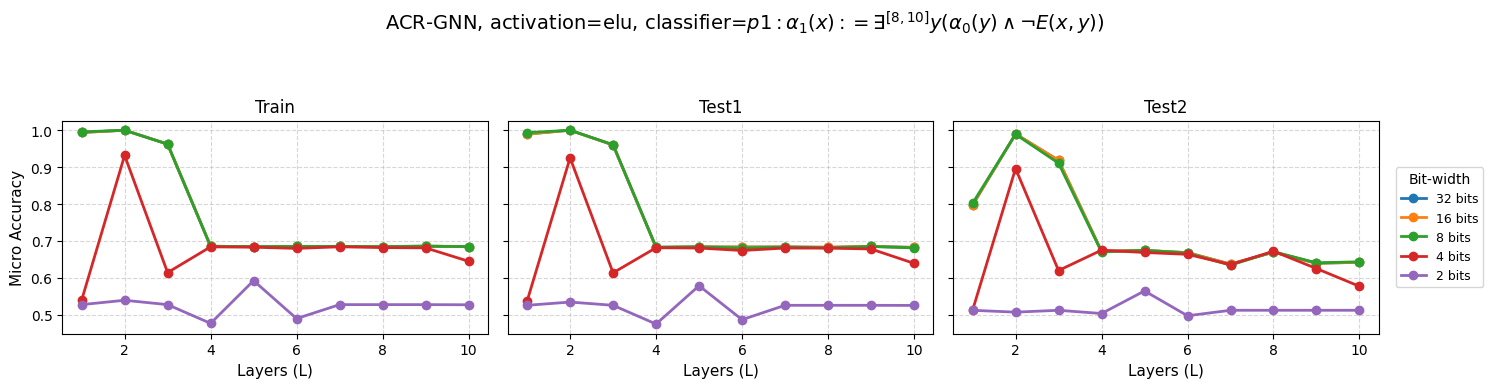

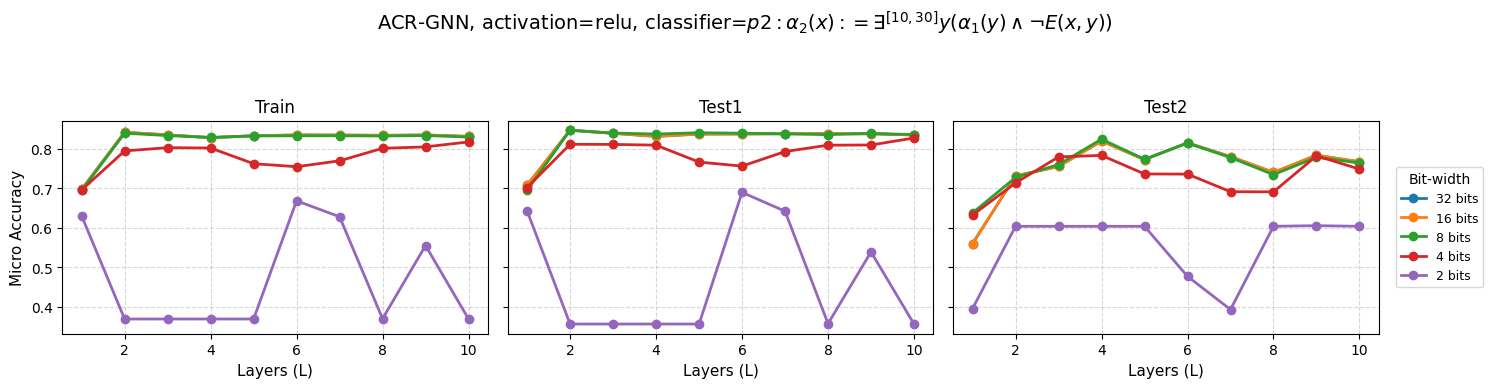

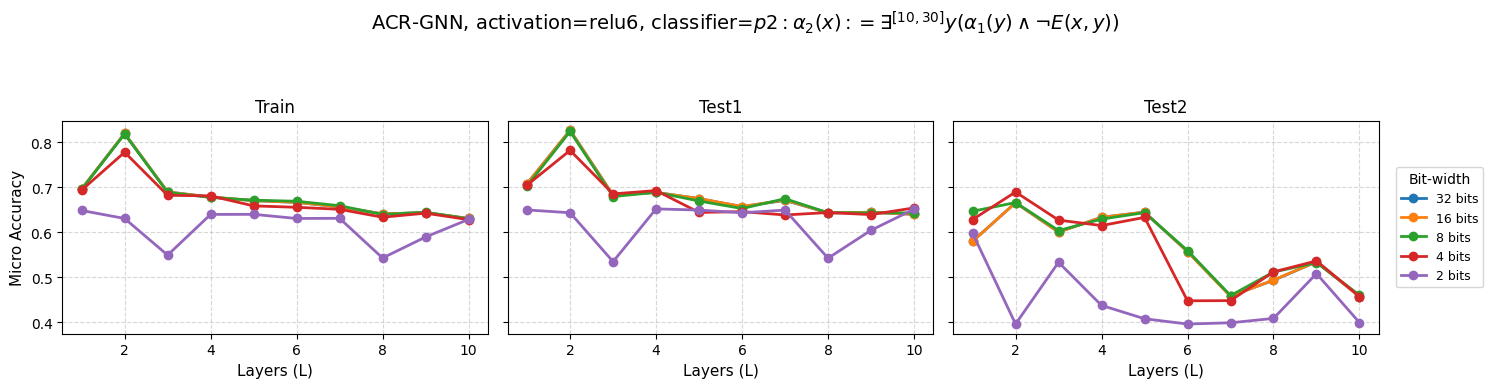

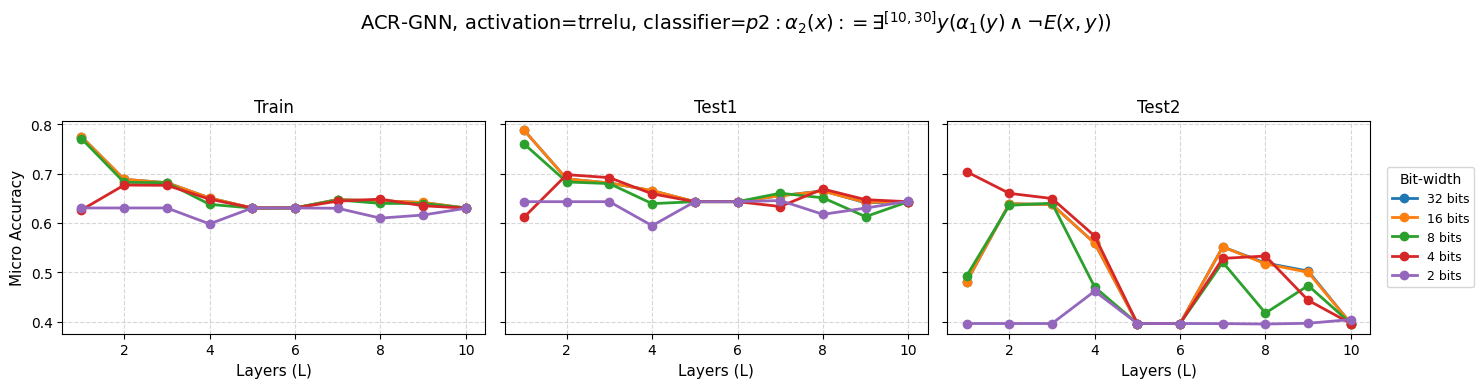

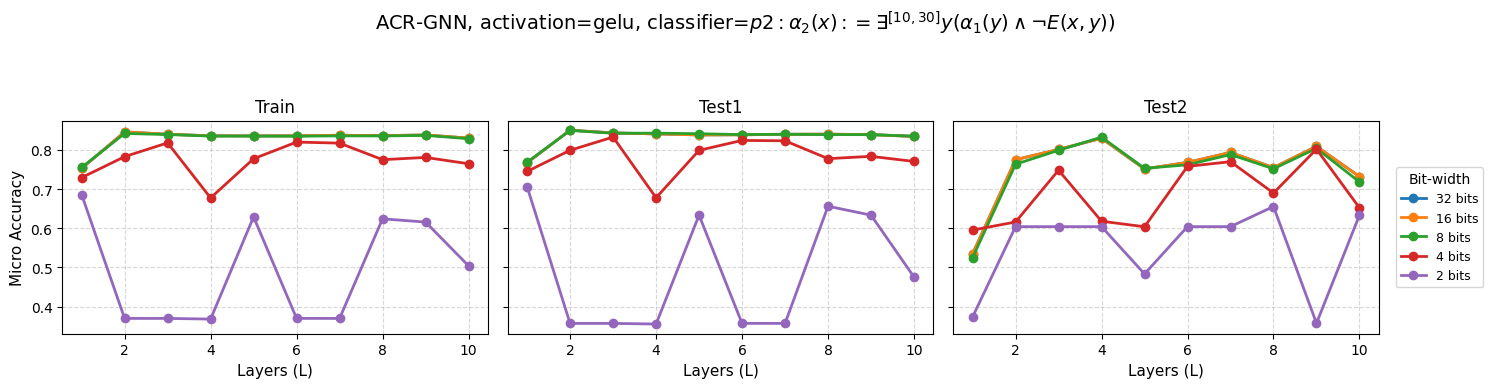

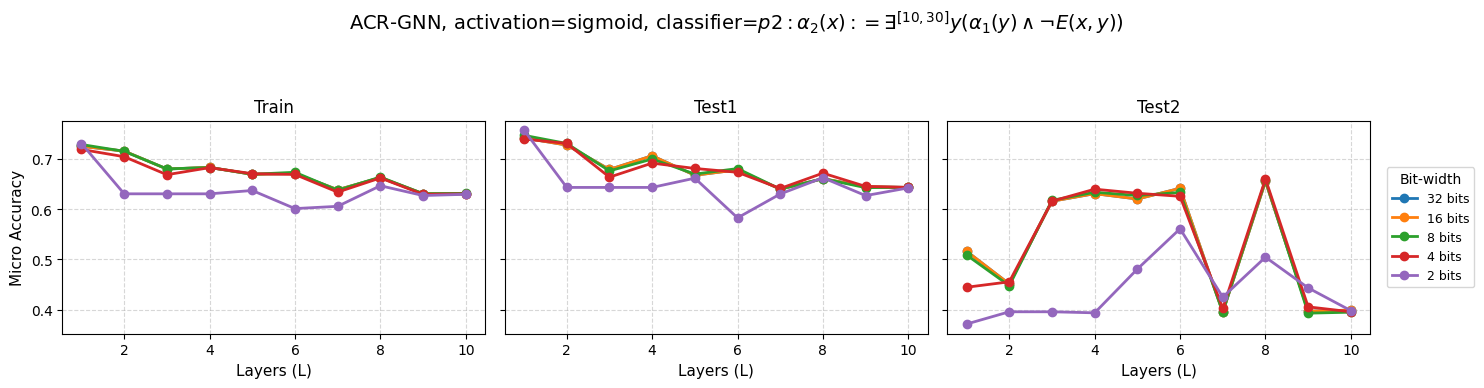

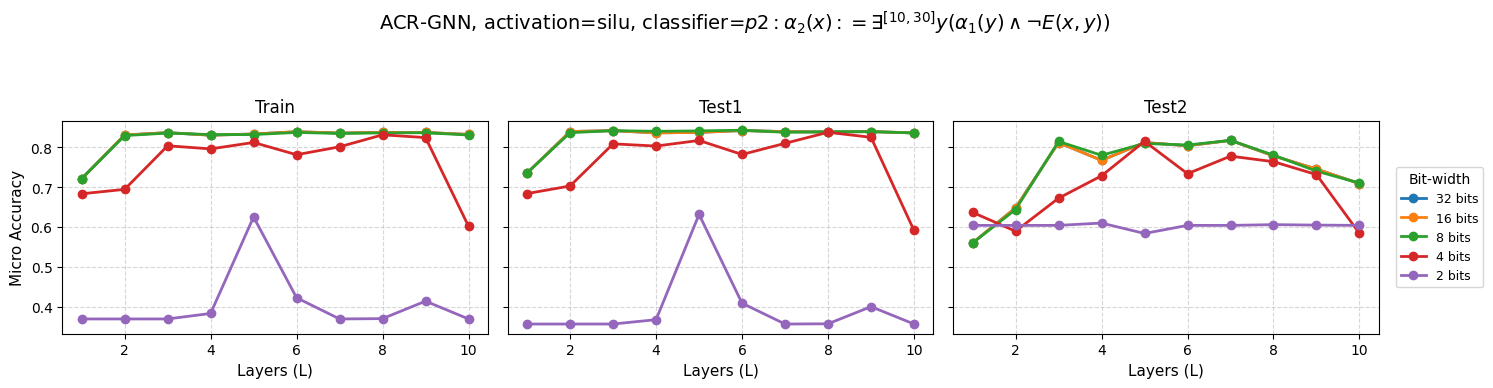

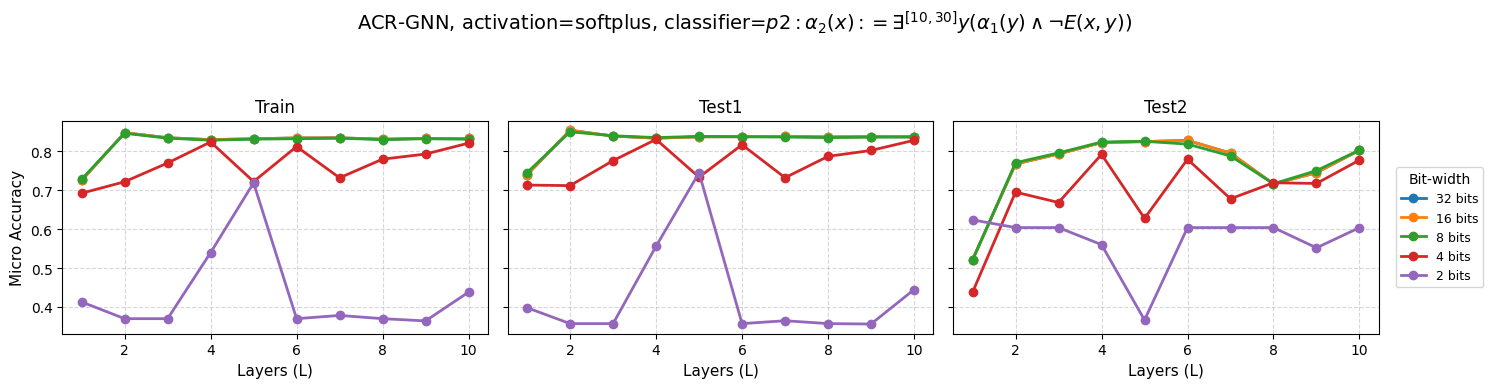

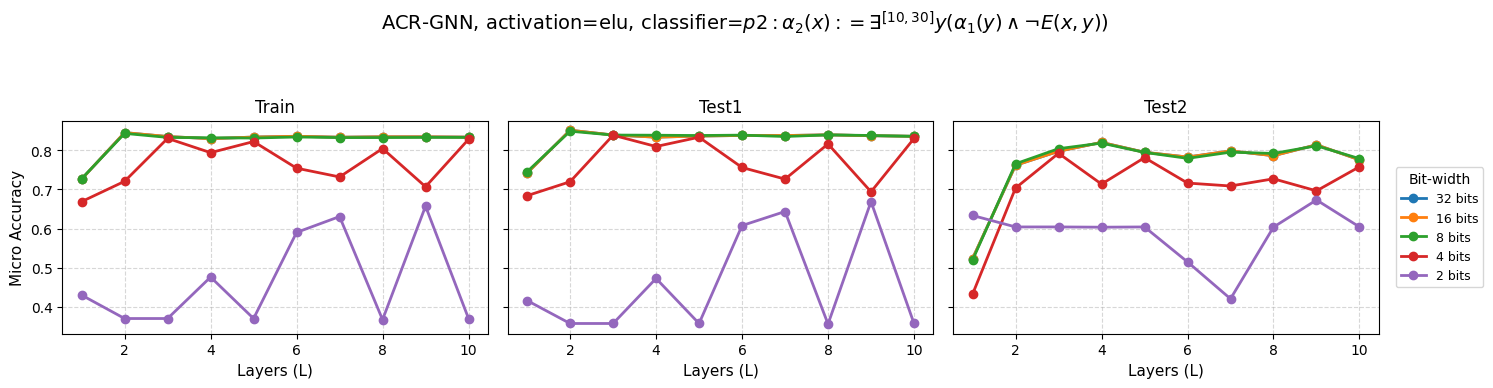

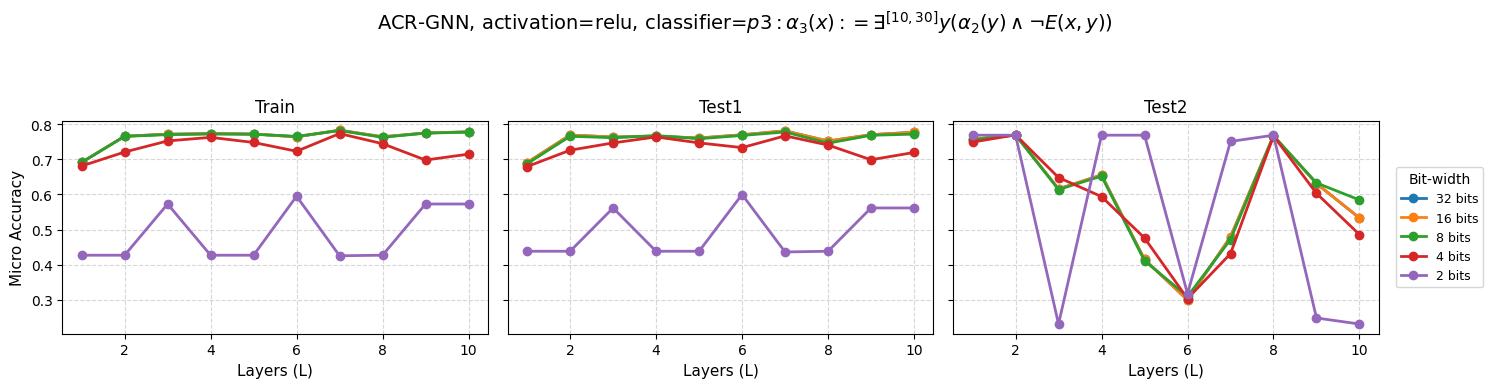

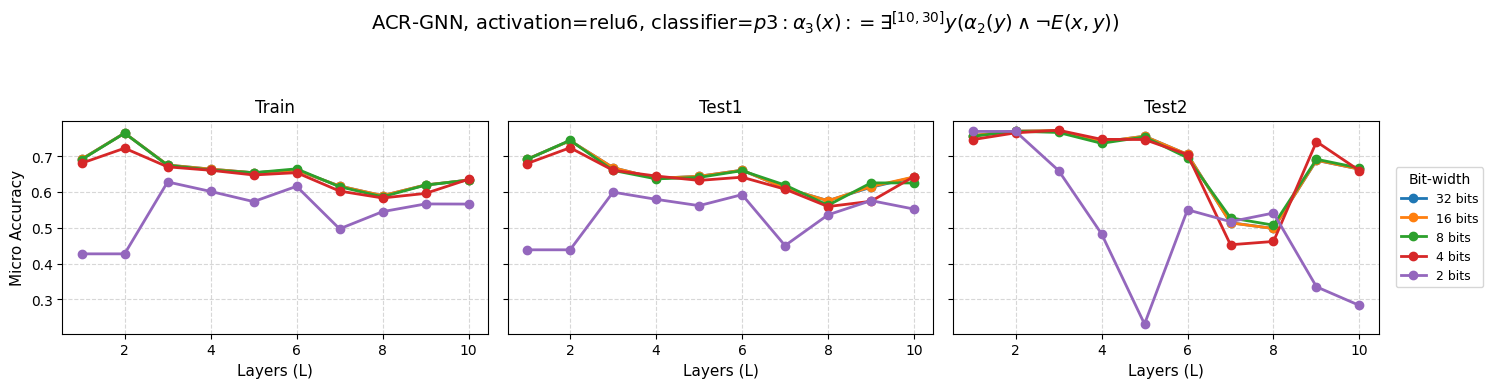

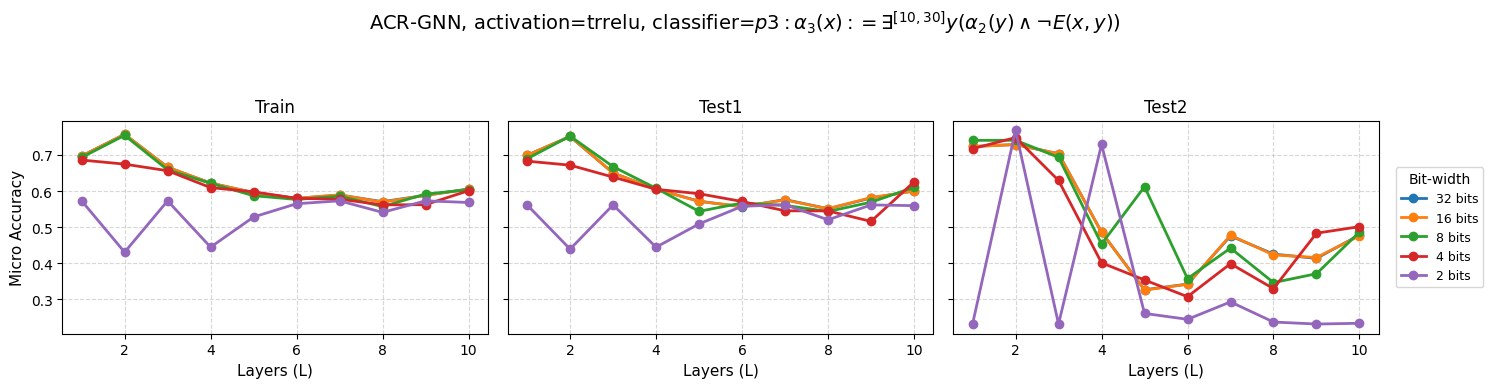

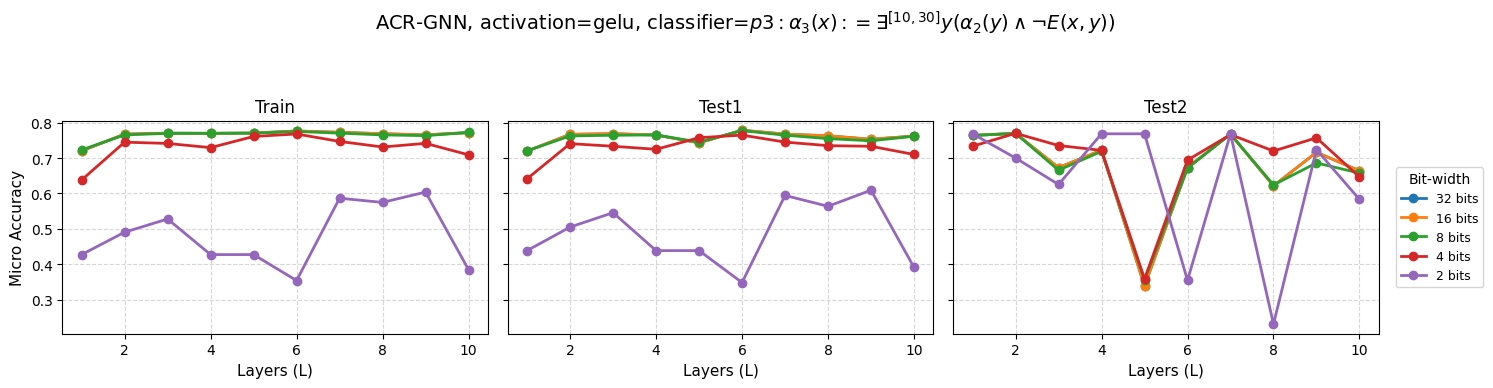

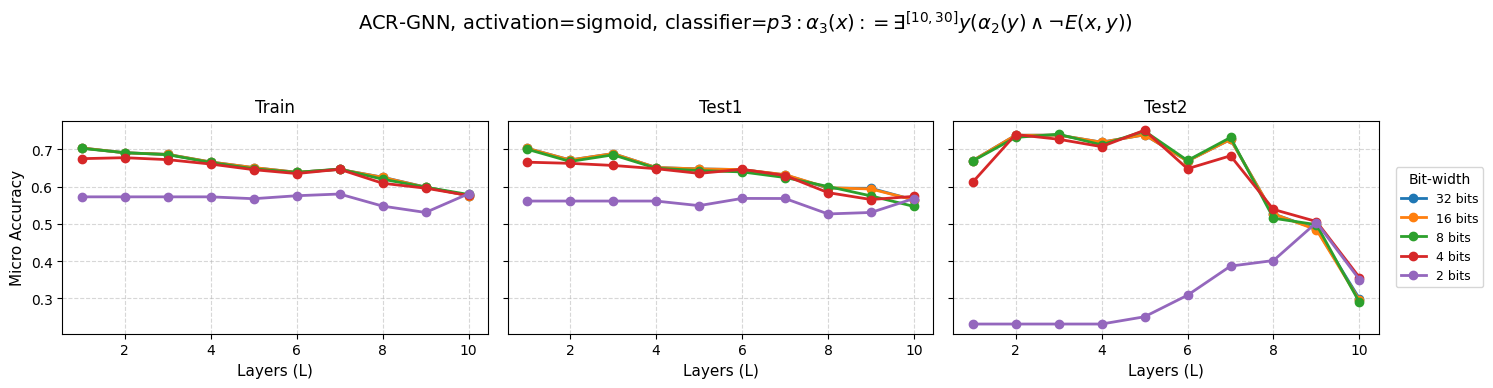

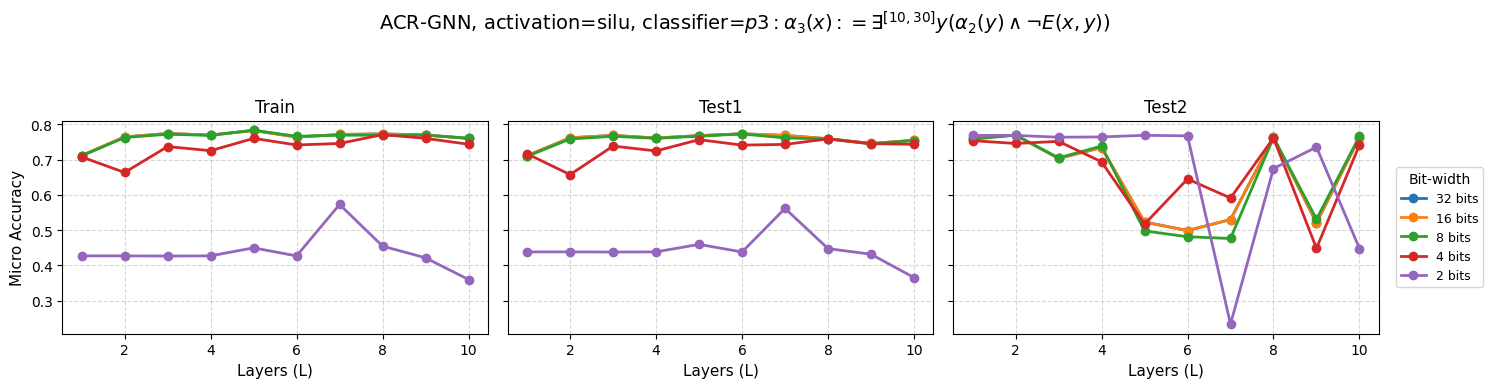

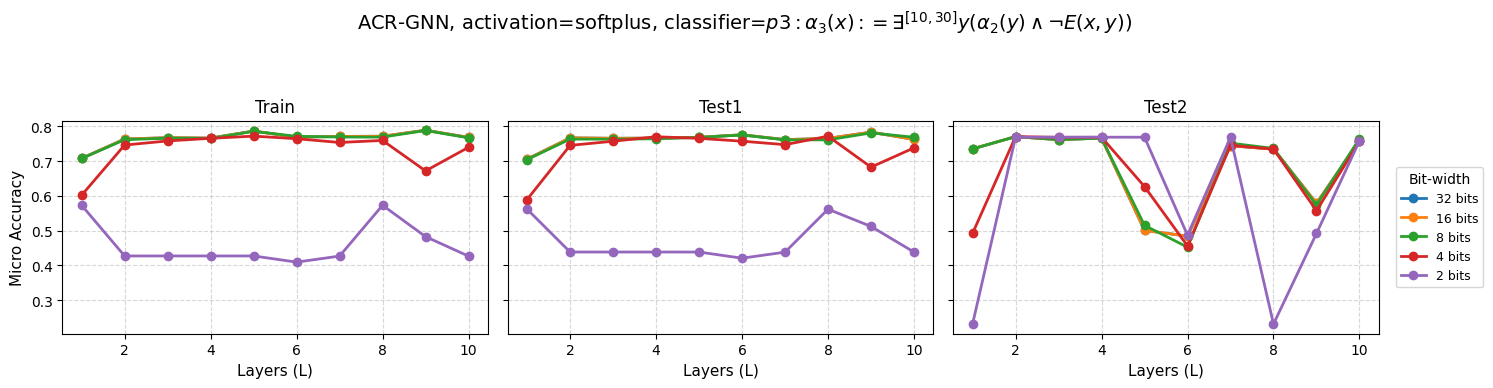

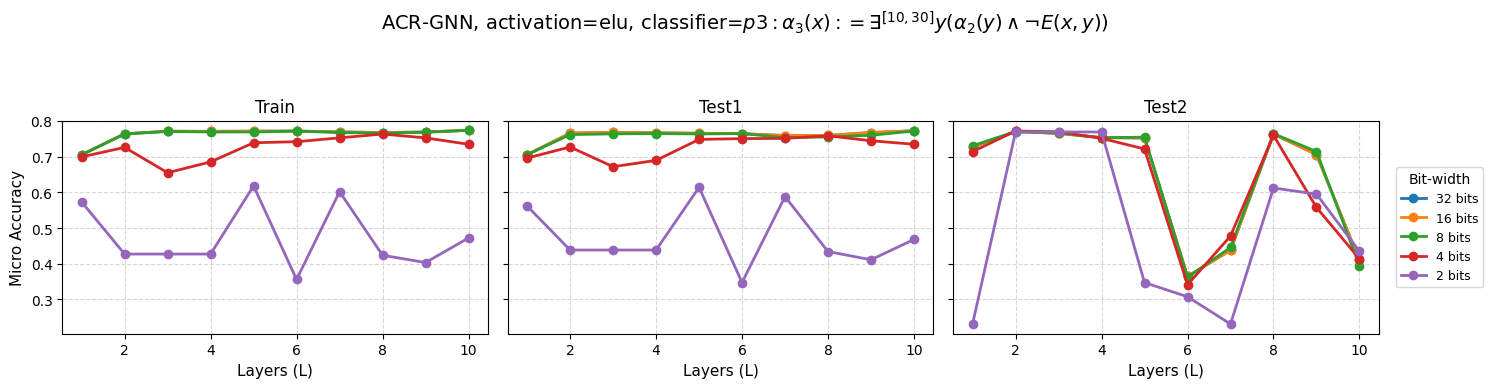

In [37]:
options_of_activations = ["relu", "relu6", "trrelu", "gelu", "sigmoid", "silu", "softplus", "elu"]
bitwidths = [32,16,8,4,2]
short_array=11
plot_comparizon_bits(options_of_activations,bitwidths,short_array)

# Detailed interactive plot

In [29]:
options_of_activations = ["relu", "relu6", "trrelu", "gelu", "sigmoid", "silu", "softplus", "elu"]
bitwidths = [32, 16, 8,7,6,5, 4, 2]


# --- Stable color map for h (works with many unique values) ---viridis
if len(bitwidths) == 1:
    color_map = {bitwidths[0]: px.colors.sample_colorscale("viridis", [0.5])[0]}
else:
    # normalize positions 0..1 along a colorscale
    positions = {h: i/(len(bitwidths)-1) for i, h in enumerate(bitwidths)}
    color_map = {h: sample_colorscale("viridis", [positions[h]])[0] for h in bitwidths}

splits = [
    ("Train", "train_micro"),
    ("Test1", "test1_micro"),
    ("Test2", "test2_micro"),
]

for selected_key in ["p1", "p2", "p3"]:
    for activation in options_of_activations:

        fig = make_subplots(
            rows=1,
            cols=len(splits),
            subplot_titles=[name for (name, _) in splits],
            shared_yaxes=True
        )

        for col_idx, (split_name, col_name) in enumerate(splits, start=1):

            for bits in bitwidths:
                key = f"{files_under_analysis}_{activation}_{bits}"
                if key not in dfs_dptq_different_bits:
                    continue

                df = dfs_dptq_different_bits[key][
                    ["key", "bits", "l", "train_micro", "test1_micro", "test2_micro"]
                ]

                df_sel = df[df["key"] == selected_key].copy()
                df_sel = df_sel[df_sel["l"] < 4].copy()
                if df_sel.empty:
                    continue

                df_sel = df_sel.sort_values("l")

                fig.add_trace(
                    go.Scatter(
                        x=df_sel["l"],
                        y=df_sel[col_name],
                        mode="lines+markers",
                        name=f"{bits} bits",
                        legendgroup=f"{bits}bits",
                        line=dict(color=color_map[bits], width=2),
                        marker=dict(color=color_map[bits]),
                        showlegend=(col_idx == len(splits))  # only show legend on last subplot
                    ),
                    row=1,
                    col=col_idx
                )

        fig.update_layout(
            title=dict(
                text=fr"ACR-GNN | Classifier = {selected_key} | Activation = {activation.capitalize()}",
                y=0.95,
                font=dict(size=20)
            ),
            margin=dict(t=120),
            legend_title="Bit-width"
        )


        for i in range(len(splits)):
            fig.update_xaxes(title_text="Layers (L)", row=1, col=i+1)

        fig.update_yaxes(title_text="Micro Accuracy", row=1, col=1)

        fig.show()


In [30]:
options_of_activations = ["relu", "relu6", "trrelu", "gelu","sigmoid", "silu", "softplus", "elu"]
bitwidths = [32, 16, 8, 7, 6, 5, 4, 2]

splits = [
    ("Train", "train_micro"),
    ("Test1", "test1_micro"),
    ("Test2", "test2_micro"),
]

rows = []

for selected_key in ["p1", "p2", "p3"]:
    for activation in options_of_activations:
        for bits in bitwidths:
            key = f"{files_under_analysis}_{activation}_{bits}"
            if key not in dfs_dptq_different_bits:
                continue

            df = dfs_dptq_different_bits[key][
                ["key", "bits", "l", "train_micro", "test1_micro", "test2_micro"]
            ].copy()

            # filter classifier
            df_sel = df[df["key"] == selected_key].copy()
            # optional: limit layers (keep if you want this)
            df_sel = df_sel[df_sel["l"] < 4].copy()

            if df_sel.empty:
                continue

            for _, row in df_sel.iterrows():
                layer = int(row["l"])

                for split_name, col_name in splits:
                    acc = float(row[col_name])
                    rows.append({
                        "classifier": selected_key,
                        "activation": activation,
                        "bitwidth": bits,
                        "split": split_name,
                        "layer": layer,
                        "accuracy": acc,
                    })

df_all = pd.DataFrame(rows)

df_all = df_all.sort_values(
    ["classifier", "activation", "split", "layer", "bitwidth"]
)



In [31]:
output_dir = "splits_pivot"
os.makedirs(output_dir, exist_ok=True)

for split_name, col_name in [
    ("Train", "train_micro"),
    ("Test1", "test1_micro"),
    ("Test2", "test2_micro")
]:

    df_split = df_all[df_all["split"] == split_name].copy()
    if df_split.empty:
        print(f"No data for {split_name}")
        continue

    pivot = df_split.pivot_table(
        index=["classifier", "activation", "layer"],
        columns="bitwidth",
        values="accuracy"
    )

    filename = f"{output_dir}/{split_name.lower()}_pivot.csv"
    pivot.to_csv(filename)
    print(f"Saved {filename}")


Saved splits_pivot/train_pivot.csv
Saved splits_pivot/test1_pivot.csv
Saved splits_pivot/test2_pivot.csv


In [32]:
pivot_files = {
    "Train": "splits_pivot/train_pivot.csv",
    "Test1": "splits_pivot/test1_pivot.csv",
    "Test2": "splits_pivot/test2_pivot.csv",
}

THRESHOLD = 0    # detect drop

all_drops = []

for split_name, filepath in pivot_files.items():
    df = pd.read_csv(filepath)
    df.reset_index(drop=True, inplace=True)

    for idx, row in df.iterrows():
        for i in range(len(bitwidths)-1):
            b1 = bitwidths[i]
            b2 = bitwidths[i+1]

            if str(b1) not in df.columns or str(b2) not in df.columns:
                continue

            a1 = row[str(b1)]
            a2 = row[str(b2)]

            # skip if missing
            if pd.isna(a1) or pd.isna(a2):
                continue

            drop = a2 - a1

            if drop < -THRESHOLD:  # ANY drop
                all_drops.append({
                    "split": split_name,
                    "classifier": row["classifier"],
                    "activation": row["activation"],
                    "layer": row["layer"],
                    "from_bits": b1,
                    "to_bits": b2,
                    "acc_from": a1,
                    "acc_to": a2,
                    "drops": drop
                })

df_drops = pd.DataFrame(all_drops)
df_drops


,split,classifier,activation,layer,from_bits,to_bits,acc_from,acc_to,drops
0,Train,p1,elu,1,7,6,0.996210,0.995731,-0.000480
1,Train,p1,elu,1,6,5,0.995731,0.825409,-0.170322
2,Train,p1,elu,1,5,4,0.825409,0.539447,-0.285962
3,Train,p1,elu,1,4,2,0.539447,0.527589,-0.011858
4,Train,p1,elu,2,16,8,0.999996,0.999960,-0.000036
...,...,...,...,...,...,...,...,...,...
933,Test2,p3,trrelu,3,32,16,0.703501,0.703464,-0.000036
934,Test2,p3,trrelu,3,16,8,0.703464,0.693432,-0.010032
935,Test2,p3,trrelu,3,6,5,0.712126,0.668459,-0.043667
936,Test2,p3,trrelu,3,5,4,0.668459,0.629340,-0.039119


In [33]:
for activation_selected in ["relu", "relu6", "trrelu", "gelu","sigmoid", "silu", "softplus", "elu"]:
    print(df_drops[(df_drops.activation == activation_selected) & (df_drops.from_bits > 4) & (df_drops.drops < -0.1)][['split', 'classifier', 'activation',  'layer',  'from_bits',  'to_bits','drops'  ]])

     split classifier activation  layer  from_bits  to_bits     drops
35   Train         p1       relu      2          6        5 -0.112864
42   Train         p1       relu      3          5        4 -0.104249
378  Test1         p1       relu      2          6        5 -0.106862
384  Test1         p1       relu      3          5        4 -0.117296
683  Test2         p1       relu      2          6        5 -0.101236
684  Test2         p1       relu      2          5        4 -0.115250
690  Test2         p1       relu      3          5        4 -0.279317
     split classifier activation  layer  from_bits  to_bits     drops
46   Train         p1      relu6      1          5        4 -0.437388
51   Train         p1      relu6      2          5        4 -0.276845
388  Test1         p1      relu6      1          5        4 -0.437130
393  Test1         p1      relu6      2          5        4 -0.265718
695  Test2         p1      relu6      1          5        4 -0.257773
700  Test2         p

In [34]:
for activation_selected in ["relu", "relu6", "trrelu", "gelu","sigmoid", "silu", "softplus", "elu"]:
    print('\\begin{table}[h!]')
    print('\\centering')
    print('\\caption{Accuracy drops across bit-width reductions for the', activation_selected,'activation function}')
    print('\\label{tab:bitwidth-drops-',activation_selected,'}')
    print(df_drops[(df_drops.activation == activation_selected) & (df_drops.from_bits > 4) & (df_drops.drops < -0.1)][['split', 'classifier', 'activation',  'layer',  'from_bits',  'to_bits','drops'  ]].to_latex(index=False))
    print('\\end{table}')

\begin{table}[h!]
\centering
\caption{Accuracy drops across bit-width reductions for the relu activation function}
\label{tab:bitwidth-drops- relu }
\begin{tabular}{lllrrrr}
\toprule
split & classifier & activation & layer & from_bits & to_bits & drops \\
\midrule
Train & p1 & relu & 2 & 6 & 5 & -0.112864 \\
Train & p1 & relu & 3 & 5 & 4 & -0.104249 \\
Test1 & p1 & relu & 2 & 6 & 5 & -0.106862 \\
Test1 & p1 & relu & 3 & 5 & 4 & -0.117296 \\
Test2 & p1 & relu & 2 & 6 & 5 & -0.101236 \\
Test2 & p1 & relu & 2 & 5 & 4 & -0.115250 \\
Test2 & p1 & relu & 3 & 5 & 4 & -0.279317 \\
\bottomrule
\end{tabular}

\end{table}
\begin{table}[h!]
\centering
\caption{Accuracy drops across bit-width reductions for the relu6 activation function}
\label{tab:bitwidth-drops- relu6 }
\begin{tabular}{lllrrrr}
\toprule
split & classifier & activation & layer & from_bits & to_bits & drops \\
\midrule
Train & p1 & relu6 & 1 & 5 & 4 & -0.437388 \\
Train & p1 & relu6 & 2 & 5 & 4 & -0.276845 \\
Test1 & p1 & relu6 & 1